In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest,f_regression
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, LabelEncoder
from xgboost import XGBRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score

# Load data

In [44]:
df = pd.read_csv("C:/Users/Saran/Downloads/dt/laptop_data.csv")
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


# Concate two columns 

In [45]:
df['company'] = df['Company'] + '_' + df['TypeName']
col = df.pop('company')
df.insert(0, 'company', col)

In [46]:
df.head()

,company,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple_Ultrabook,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple_Ultrabook,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP_Notebook,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple_Ultrabook,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple_Ultrabook,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


## Remove unwanted

In [47]:
df.drop(columns = ['Unnamed: 0','Company','TypeName'],inplace = True)
df.head()

,company,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple_Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple_Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP_Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple_Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple_Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


# Check for Null values

In [61]:
df.isnull().sum()

company             0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

# Check for outliers

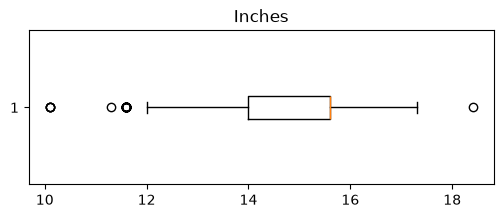

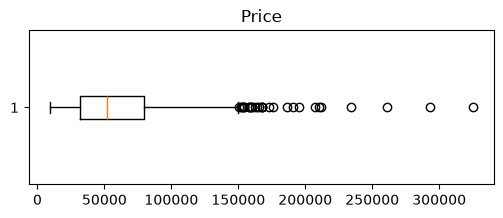

In [62]:

import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    plt.figure(figsize=(6, 2))
    plt.boxplot(df[col], orientation="horizontal")
    plt.title(col)
    plt.show()#temp atmos

## Remove GB and Kg from the column

In [63]:
df['Ram'] = df['Ram'].str.replace('GB', '', regex=False).astype(int)
df['Weight'] = df['Weight'].str.replace('kg', '', regex=False).astype(float)

In [64]:
print(df[['Ram', 'Weight']].head())
print(df.dtypes)

   Ram  Weight
0    8    1.37
1    8    1.34
2    8    1.86
3   16    1.83
4    8    1.37
company                 str
Inches              float64
ScreenResolution        str
Cpu                     str
Ram                   int64
Memory                  str
Gpu                     str
OpSys                   str
Weight              float64
Price               float64
dtype: object


# XGRegressor model using pipeline

In [65]:
# Split X and y
X = df.drop(columns='Price')
y = df['Price']


# Separate numerical and categorical columns after testing
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    #('scaler', RobustScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Final pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    #("feature_selection", SelectKBest(score_func=f_regression, k='all')),
    ('model',XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0,
        reg_alpha=0,
        reg_lambda=1,
        random_state=42,
        objective='reg:squarederror'
    ))
])


# Train model
pipeline.fit(X_train, y_train)

# Prediction
y_pred = pipeline.predict(X_test)

# Evaluation
print("Accuracy :", r2_score(y_test, y_pred))

C:\Users\Saran\AppData\Local\Temp\ipykernel_10944\2927698656.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns


Accuracy : 0.8609778782349065


In [66]:
# Training predictions
y_train_pred = pipeline.predict(X_train)

# Training accuracy
print("Training Accuracy:", r2_score(y_train, y_train_pred))

Training Accuracy: 0.9652812635818718


In [67]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error
)

# Predictions
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

print("Training Metrics")
print("----------------")
print("R² Score :", r2_score(y_train, y_train_pred))
print("MAE      :", mean_absolute_error(y_train, y_train_pred))
print("MSE      :", mean_squared_error(y_train, y_train_pred))
print("RMSE     :", root_mean_squared_error(y_train, y_train_pred))

print("\nTesting Metrics")
print("----------------")
print("R² Score :", r2_score(y_test, y_test_pred))
print("MAE      :", mean_absolute_error(y_test, y_test_pred))
print("MSE      :", mean_squared_error(y_test, y_test_pred))
print("RMSE     :", root_mean_squared_error(y_test, y_test_pred))

Training Metrics
----------------
R² Score : 0.9652812635818718
MAE      : 4947.24170442537
MSE      : 46058929.61402143
RMSE     : 6786.672941436137

Testing Metrics
----------------
R² Score : 0.8609778782349065
MAE      : 9519.372374936062
MSE      : 211327247.64956525
RMSE     : 14537.099010791846


In [68]:
import joblib

joblib.dump(pipeline, "pipeline_.pkl")

['pipeline_.pkl']

# Streamlit Connect

In [73]:
company_list = sorted(df["company"].unique())
ScreenResolution_list = sorted(df['ScreenResolution'].unique())
Cpu_list = sorted(df['Cpu'].unique())
Memory_list = sorted(df['Memory'].unique())
Gpu_list = sorted(df['Gpu'].unique())
OpSys_list = sorted(df["OpSys"].unique())

In [78]:
lists = {
    "company": sorted(df["company"].unique()),
    "ScreenResolution": sorted(df["ScreenResolution"].unique()),
    "Cpu": sorted(df["Cpu"].unique()),
    "Memory": sorted(df["Memory"].unique()),
    "Gpu": sorted(df["Gpu"].unique()),
    "OpSys": sorted(df["OpSys"].unique())
}

joblib.dump(lists, "lists.pkl")

['lists.pkl']

In [79]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd

# Load trained pipeline
pipeline = joblib.load("pipeline.pkl")

lists = joblib.load("lists.pkl")

company_list = lists["company"]
ScreenResolution_list = lists["ScreenResolution"]
Cpu_list = lists["Cpu"]
Memory_list = lists["Memory"]
Gpu_list = lists["Gpu"]
OpSys_list = lists["OpSys"]

st.set_page_config(page_title="Laptop Price Predictor", page_icon="💻")

st.title("💻 Laptop Price Predictor")
st.write("Enter the laptop specifications below to predict its price.")

with st.form("prediction_form", clear_on_submit=True):
    company = st.selectbox("Company", company_list)
    
    inches = st.number_input(
        "Screen Size (Inches)",
        min_value=10.0,
        max_value=20.0,
        value=15.6
    )
    
    screen_resolution = st.selectbox(
        "Screen Resolution",ScreenResolution_list)
    
    cpu = st.selectbox(
        "CPU",Cpu_list)
    
    ram = st.selectbox("RAM (GB)", [2, 4, 8, 16, 32, 64])
    
    memory = st.selectbox(
        "Storage",Memory_list)
    
    gpu = st.selectbox(
        "GPU",Gpu_list)
    
    os = st.selectbox(
        "Operating System",OpSys_list)
    
    weight = st.number_input(
        "Weight (kg)",
        min_value=0.5,
        max_value=5.0,
        value=2.0
    )
    submit = st.form_submit_button("Predict Price")

if submit:

    input_df = pd.DataFrame({
        'company': [company],
        'Inches': [inches],
        'ScreenResolution': [screen_resolution],
        'Cpu': [cpu],
        'Ram': [ram],
        'Memory': [memory],
        'Gpu': [gpu],
        'OpSys': [os],
        'Weight': [weight]
    })

    prediction = pipeline.predict(input_df)[0]

    st.success(f"Estimated Laptop Price: ₹ {prediction:,.2f}")

if st.button("Clear"):
    st.session_state.clear()
    st.rerun()

Overwriting app.py


In [80]:
!streamlit run app.py

^C
